Импорт необходимых модулей:

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

# from math import isqrt

### Генерируем точки + строим графики и изображения

In [2]:
total_points_sqrt = 3163
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10004569


Запускаем сценарий сборки

In [3]:
os.system("make")

0

Запускаем генерацию точек

In [4]:
os.system("release/executable --xs64 " + str(total_points) + " 0 1")
os.system("release/executable --xs1024 " + str(total_points) + " 0 1")
os.system("release/executable --mt19937 " + str(total_points) + " 0 1")

0

Подгружаем сгенерированные выборки:

In [5]:
x64      = pd.read_csv("xor_shift_64__sample.csv")
x1024    = pd.read_csv("xor_shift_1024__sample.csv")
mt19937  = pd.read_csv("mt19937__sample.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [6]:
x64.head()

,randoms
0,0.027664
1,0.156697
2,0.654250
3,0.079530
4,0.256672


Описательная статистика:

In [7]:
x64['randoms'].describe()

count    1.000457e+07
mean     5.000721e-01
std      2.886527e-01
min      3.755540e-07
25%      2.501610e-01
50%      5.000640e-01
75%      7.499700e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

(9500.0, 10550.0)

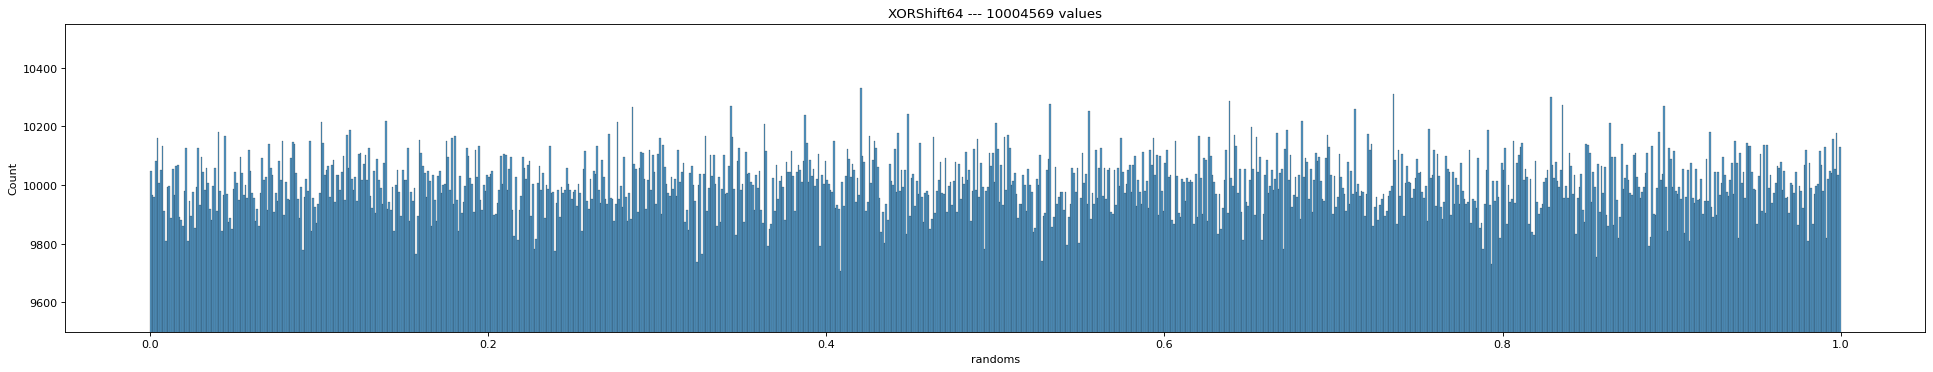

In [8]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=1000).set(title='XORShift64 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [9]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [10]:
data.shape

(10004569, 1)

In [11]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[  7  39 166 ...  99 142  30]
 [ 59 147  11 ...  97 142  26]
 [174  75 107 ...  70 158  82]
 ...
 [ 71  25 245 ...  77 233 134]
 [ 38  13  31 ...  21   5 231]
 [110 173  54 ... 197 134 172]]


In [12]:
data.shape

(3163, 3163)

In [13]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9500.0, 10550.0)

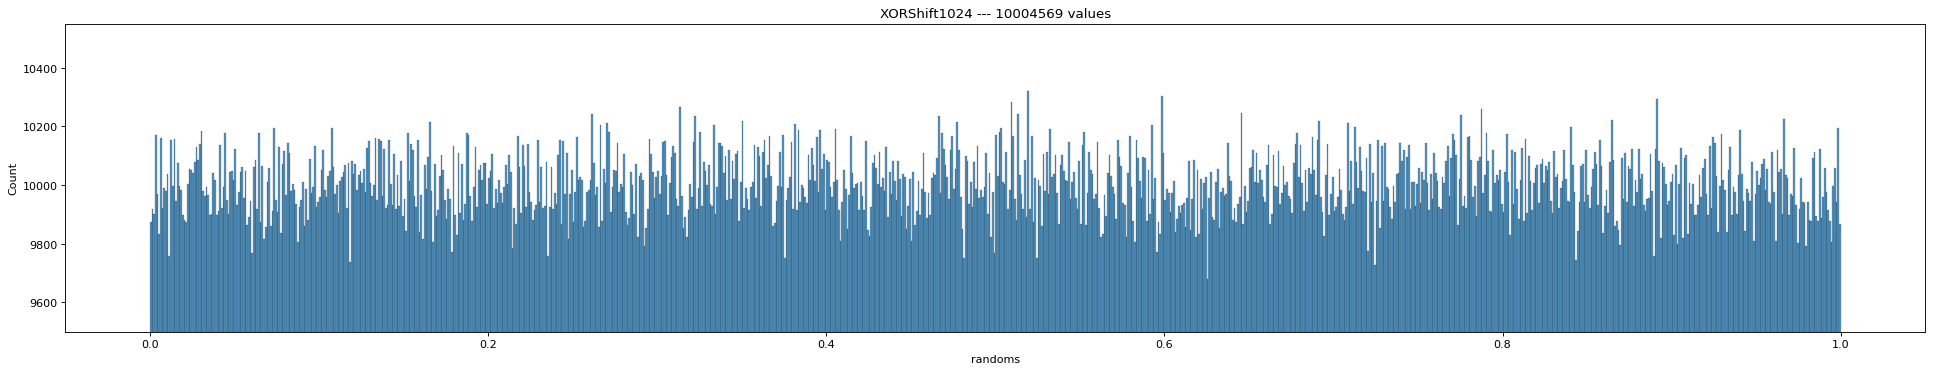

In [14]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=1000).set(title='XORShift1024 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [15]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [16]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9500.0, 10550.0)

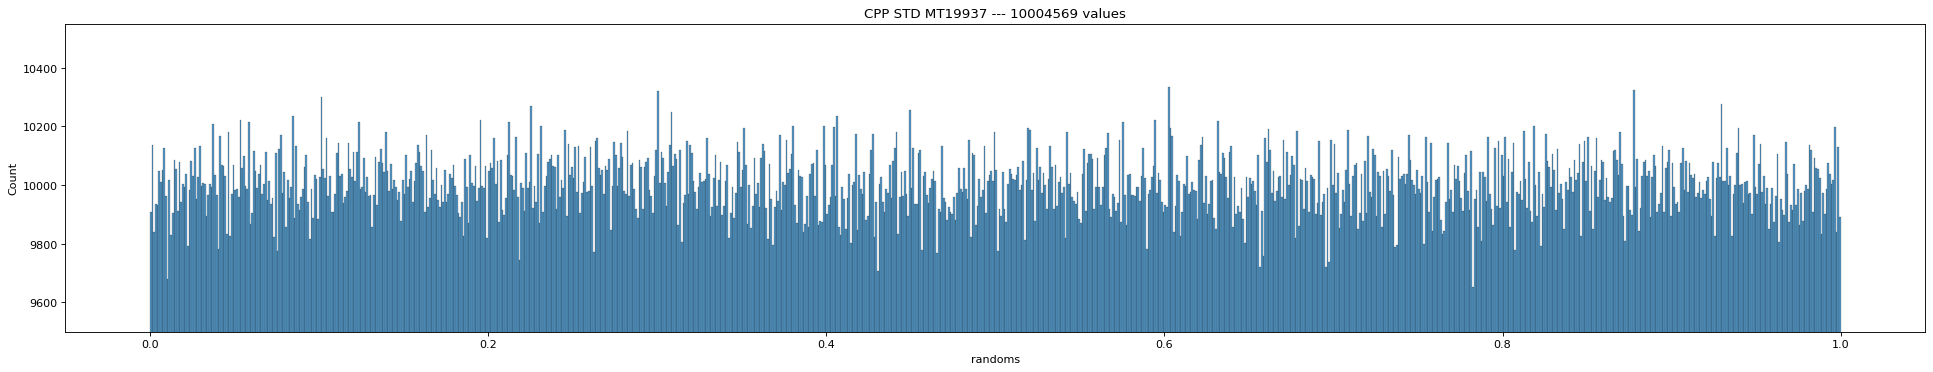

In [17]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=1000).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [18]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [19]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)